In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2

# Load data

In [36]:
train_dir = 'data/seg_train'
test_dir = 'data/seg_test'
IMAGE_SIZE = (128, 128)

In [37]:
def load_data(dir):
    labels = []
    images = []
    classes = []

    for i, label in enumerate(os.listdir(dir)):
        classes.append(label)
        label_dir = os.path.join(dir, label)
        for img_dir in os.listdir(label_dir):
            img = cv2.imread(os.path.join(label_dir, img_dir))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, IMAGE_SIZE)
            images.append(img)
            labels.append(i)
    return np.array(images), np.array(labels), classes

In [38]:
X_train, y_train, classes = load_data(train_dir)
X_test, y_test, classes = load_data(test_dir)

# Exploratory Data Analysis

In [39]:
print("Name of classes: ", classes)
print("Train shape: ", X_train.shape)
print("Test shape: ", X_test.shape)

Name of classes:  ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Train shape:  (14034, 128, 128, 3)
Test shape:  (3000, 128, 128, 3)


## Class distribution

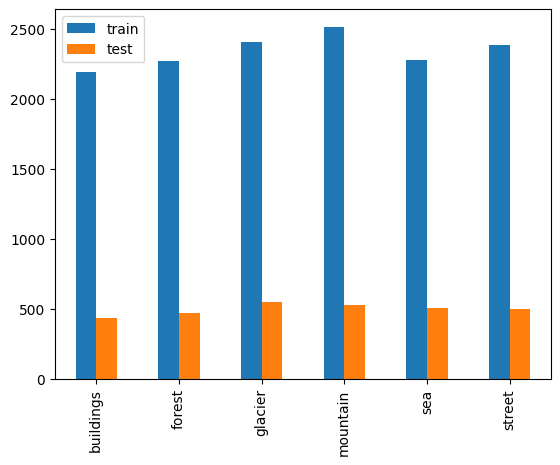

In [40]:
_, train_class_count = np.unique(y_train, return_counts=True)
_, test_class_count = np.unique(y_test, return_counts=True)
pd.DataFrame(
    {'train' : train_class_count,
     'test' : test_class_count},
    index=classes
).plot.bar()
plt.show()

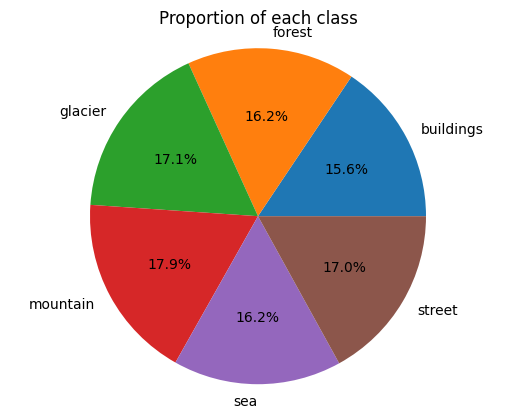

In [41]:
plt.pie(train_class_count, explode=(0, 0, 0, 0, 0, 0), labels=classes, autopct='%1.1f%%')
plt.axis('equal')
plt.title('Proportion of each class')
plt.show()

### -> After analyzing, the class distribution is fairly balance

## Examine samples

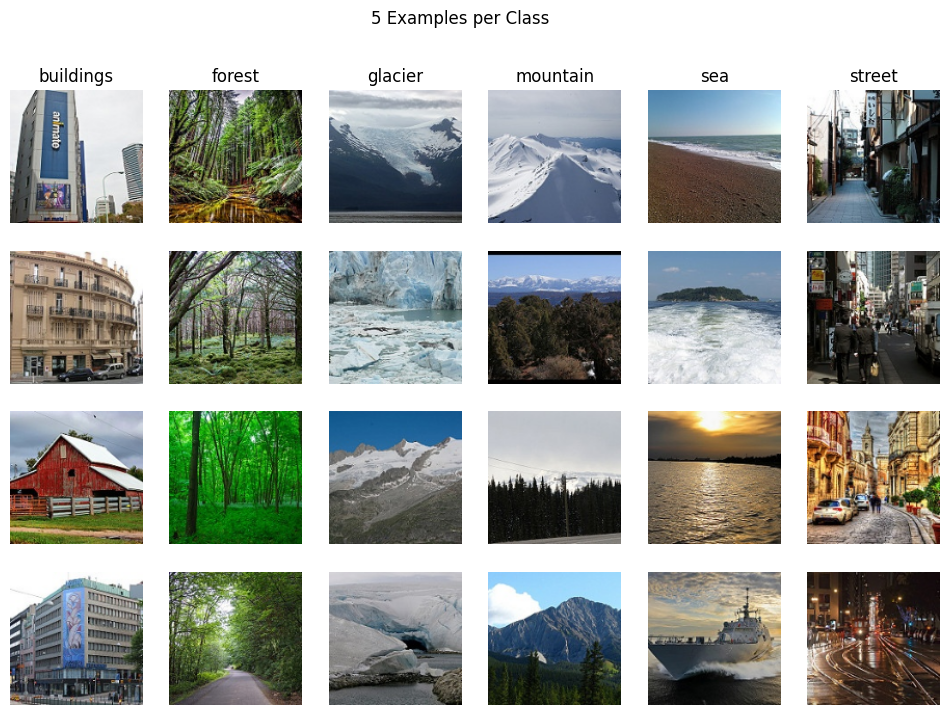

In [42]:
num_classes = len(classes)
num_samples = 4

plt.figure(figsize=(12, 8))

for i in range(num_classes):
    idxs = np.random.choice(np.where(y_train == i)[0], num_samples)
    
    for j, idx in enumerate(idxs):
        plt.subplot(num_samples, num_classes, j*num_classes + i + 1)
        plt.imshow(X_train[idx])
        plt.axis("off")
        
        if j == 0:
            plt.title(classes[i])

plt.suptitle("5 Examples per Class")
plt.show()

## Data statistics

In [43]:
X_train = X_train / 255.0
X_test = X_test / 255.0

### Pixel distribution

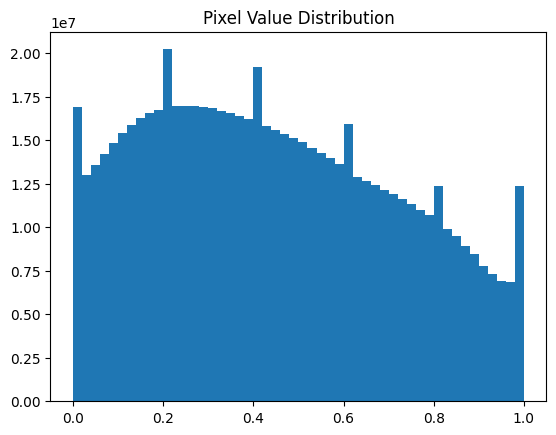

In [44]:
plt.hist(X_train.flatten(), bins=50)
plt.title("Pixel Value Distribution")
plt.show()

### Mean images

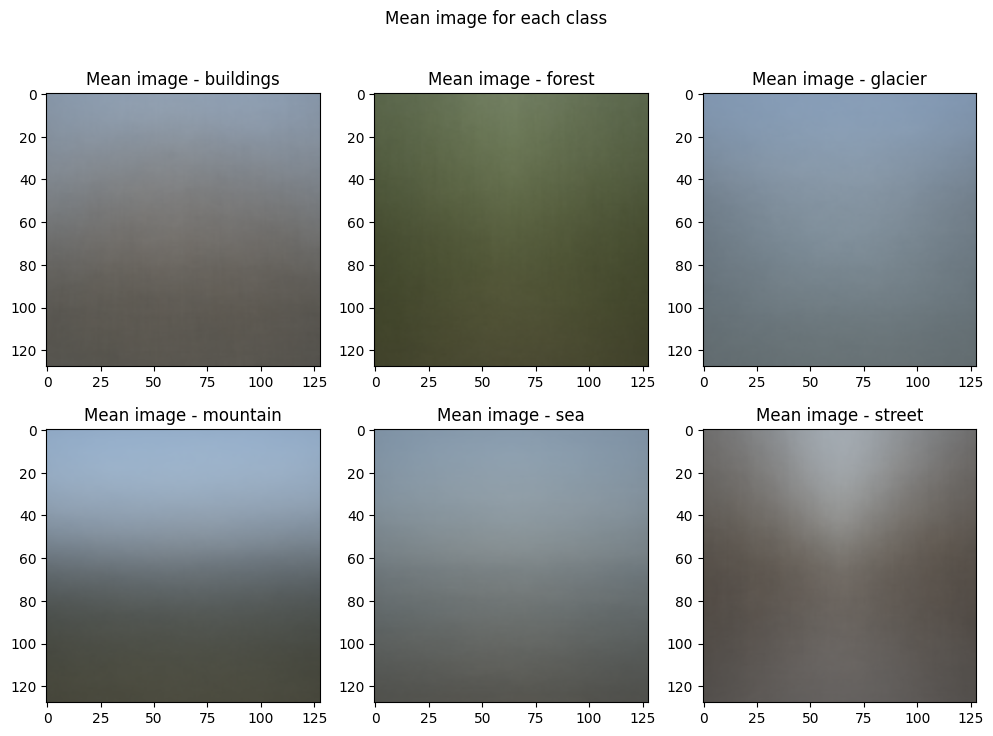

In [45]:
plt.figure(figsize=(12,8))
for i in range(num_classes):
    imgs = X_train[y_train == i]
    mean_img = imgs.mean(axis=0)
    
    plt.subplot(2, 3, i + 1)
    plt.imshow(mean_img)
    plt.title(f"Mean image - {classes[i]}")
plt.suptitle("Mean image for each class")
plt.show()

### RGB Distribution

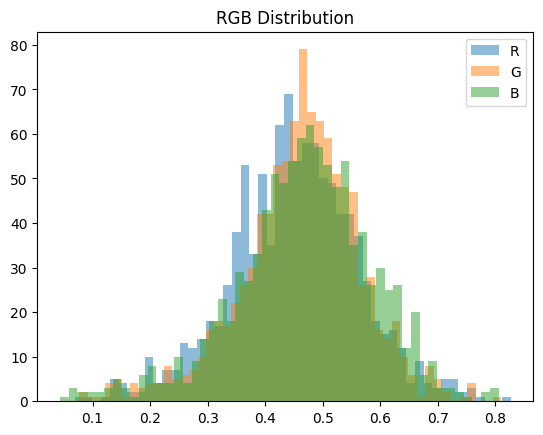

In [46]:
r, g, b = [], [], []

for img in X_train[:1000]:
    r.append(img[:,:,0].mean())
    g.append(img[:,:,1].mean())
    b.append(img[:,:,2].mean())

plt.hist(r, bins=50, alpha=0.5, label='R')
plt.hist(g, bins=50, alpha=0.5, label='G')
plt.hist(b, bins=50, alpha=0.5, label='B')
plt.legend()
plt.title("RGB Distribution")
plt.show()

### Image quality check

Blurry images detected: 38/14034 (0.27%)


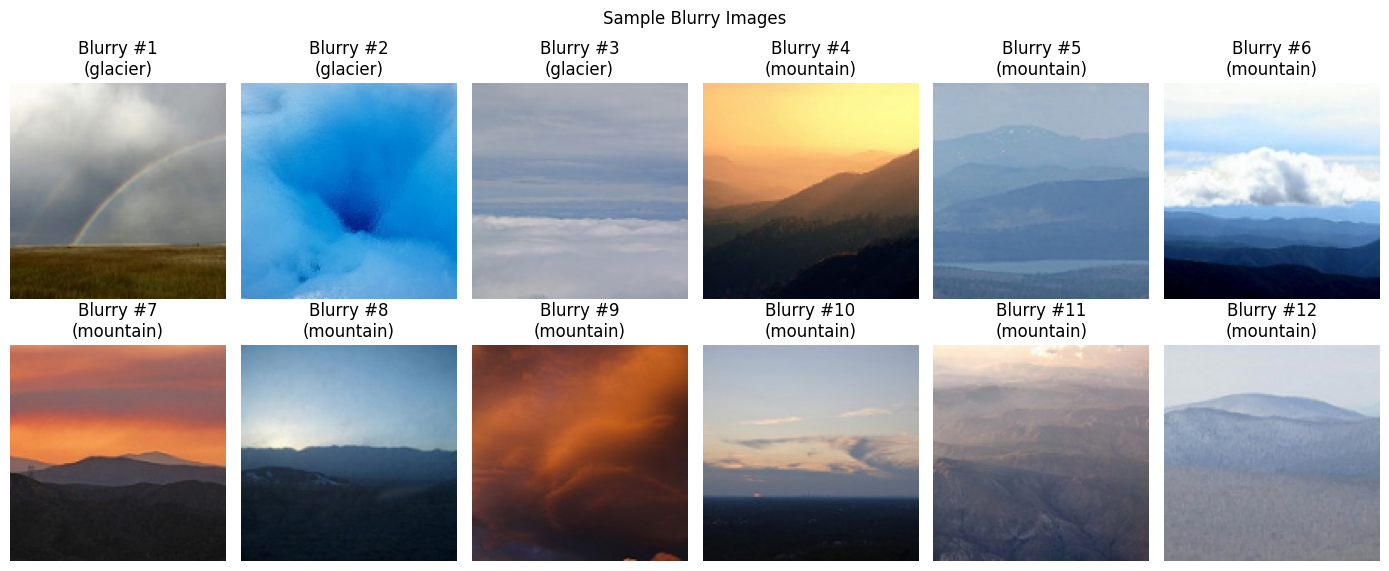

In [47]:
# Image Quality Check - Detect Blurry Images
from scipy.ndimage import laplace

def detect_blurry(img, threshold=100):
    """Detect blurry images using Laplacian variance"""
    gray = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
    laplacian_var = cv2.Laplacian(gray, cv2.CV_64F).var()
    return laplacian_var < threshold

# Check for blurry images
blurry_count = sum([detect_blurry(img) for img in X_train])
print(f"Blurry images detected: {blurry_count}/{len(X_train)} ({blurry_count/len(X_train)*100:.2f}%)")

# Display blurry image samples
blurry_indices = np.where([detect_blurry(img) for img in X_train])[0][:12]
num_blurry_show = min(12, len(blurry_indices))

if num_blurry_show > 0:
    plt.figure(figsize=(14, 6))
    for idx, i in enumerate(blurry_indices[:num_blurry_show]):
        plt.subplot(2, 6, idx + 1)
        plt.imshow(X_train[i])
        plt.title(f"Blurry #{idx+1}\n({classes[y_train[i]]})")
        plt.axis('off')
    
    plt.suptitle("Sample Blurry Images")
    plt.tight_layout()
    plt.show()
else:
    print("No blurry images detected!")

In [48]:
# Check for missing values and invalid dimensions
print(f"Missing values in X_train: {np.isnan(X_train).sum()}")
print(f"Missing values in X_test: {np.isnan(X_test).sum()}")
print(f"Images with invalid shapes: {sum(1 for img in X_train if img.shape != (128, 128, 3))}")

Missing values in X_train: 0
Missing values in X_test: 0
Images with invalid shapes: 0
Missing values in X_test: 0
Images with invalid shapes: 0


### Outlier detection

Outlier images detected: 19/14034 (0.14%)



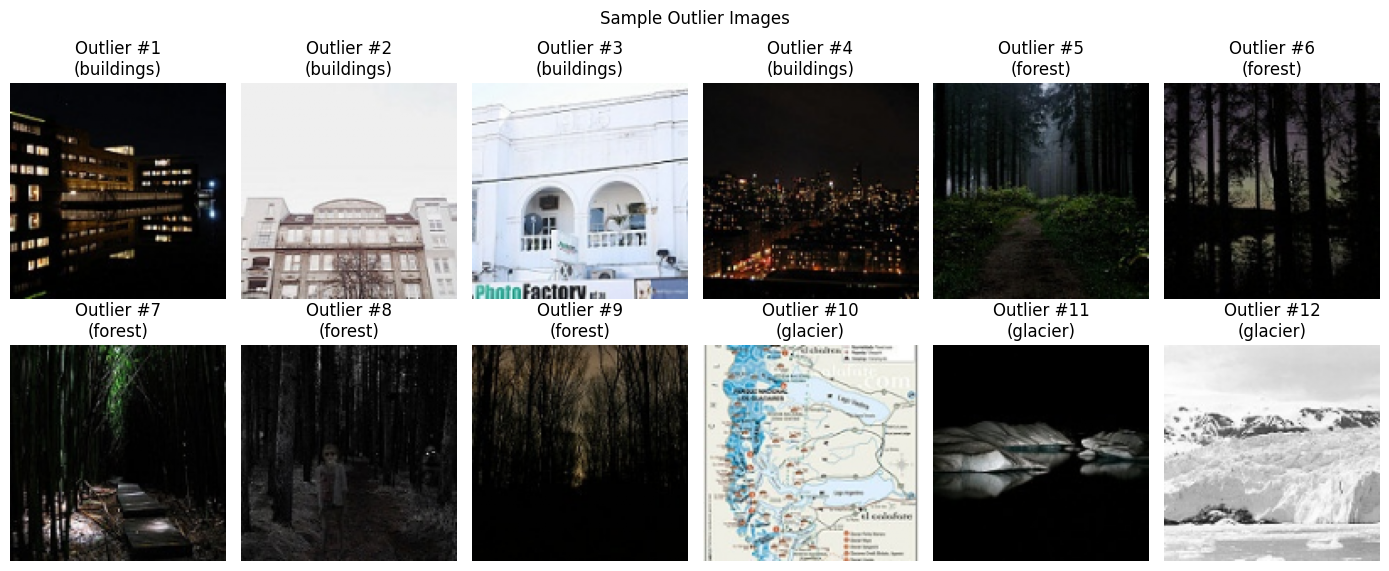

In [49]:
### Outlier detection

# Outlier Detection - Pixel Value Distribution Analysis
def detect_outlier_images(X, threshold_std=3):
    """Detect images with unusual pixel distributions"""
    pixel_means = X.reshape(X.shape[0], -1).mean(axis=1)
    mean_of_means = pixel_means.mean()
    std_of_means = pixel_means.std()
    
    outliers = np.abs(pixel_means - mean_of_means) > (threshold_std * std_of_means)
    return outliers

outliers = detect_outlier_images(X_train)
outlier_count = outliers.sum()
print(f"Outlier images detected: {outlier_count}/{len(X_train)} ({outlier_count/len(X_train)*100:.2f}%)\n")

# Display outlier samples
outlier_indices = np.where(outliers)[0][:12]
num_to_show = min(12, len(outlier_indices))

plt.figure(figsize=(14, 6))
for idx, i in enumerate(outlier_indices[:num_to_show]):
    plt.subplot(2, 6, idx + 1)
    plt.imshow(X_train[i])
    plt.title(f"Outlier #{idx+1}\n({classes[y_train[i]]})")
    plt.axis('off')

plt.suptitle("Sample Outlier Images")
plt.tight_layout()
plt.show()

### Correlation Analysis

PCA Explained Variance: [0.24813845 0.13355484]
Cumulative Variance: 0.3817


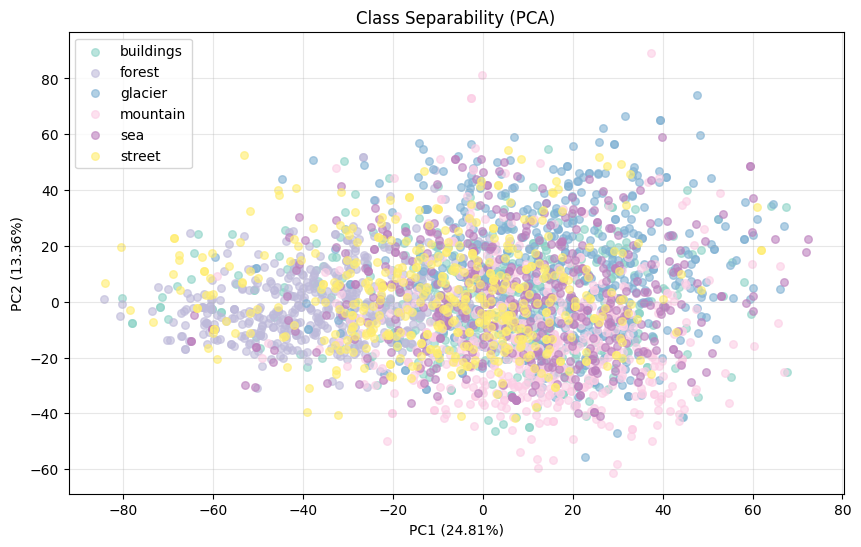

In [50]:
# Correlation Analysis - Feature Extraction per Class
from sklearn.decomposition import PCA

# Flatten images and perform PCA
idxs = np.array(np.random.choice(len(X_train), 3000))
X_train_sample = X_train[idxs]
X_train_flat = X_train_sample.reshape(len(idxs), -1)
y_train_sample = y_train[idxs]
# PCA for visualization
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_flat)

print(f"PCA Explained Variance: {pca.explained_variance_ratio_}")
print(f"Cumulative Variance: {pca.explained_variance_ratio_.sum():.4f}")

# Plot class separability in PCA space
plt.figure(figsize=(10, 6))
colors = plt.cm.Set3(np.linspace(0, 1, num_classes))
for i, cls in enumerate(classes):
    mask = y_train_sample == i
    plt.scatter(X_train_pca[mask, 0], X_train_pca[mask, 1], 
                label=cls, alpha=0.6, c=[colors[i]], s=30)
plt.legend()
plt.title("Class Separability (PCA)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%})")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%})")
plt.grid(True, alpha=0.3)
plt.show()



=== Feature Correlation Analysis ===
buildings: R=0.446, G=0.458, B=0.465
forest: R=0.324, G=0.350, B=0.237
glacier: R=0.469, G=0.529, B=0.577
forest: R=0.324, G=0.350, B=0.237
glacier: R=0.469, G=0.529, B=0.577
mountain: R=0.440, G=0.482, B=0.506
sea: R=0.458, G=0.486, B=0.502
mountain: R=0.440, G=0.482, B=0.506
sea: R=0.458, G=0.486, B=0.502
street: R=0.428, G=0.414, B=0.403

=== Cross-Class Correlation (Mean Images) ===
street: R=0.428, G=0.414, B=0.403

=== Cross-Class Correlation (Mean Images) ===


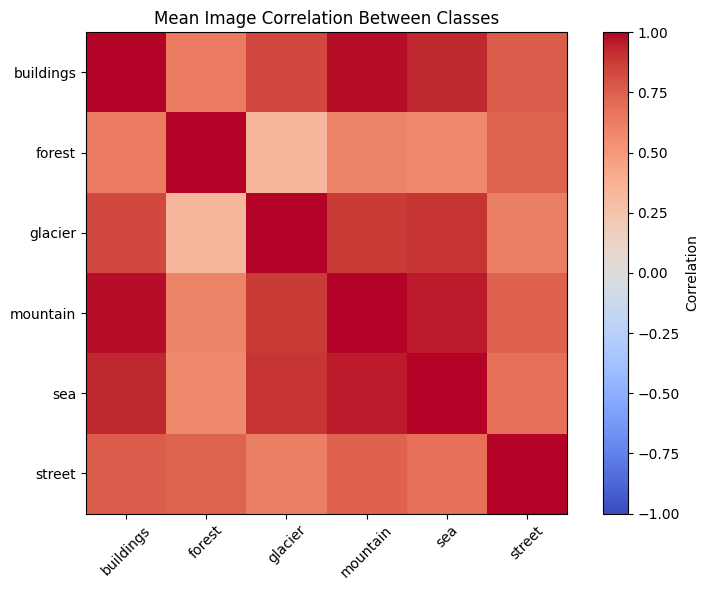


Class Correlation Matrix:
           buildings  forest  glacier  mountain    sea  street
buildings      1.000   0.638    0.835     0.979  0.931   0.763
forest         0.638   1.000    0.335     0.596  0.574   0.730
glacier        0.835   0.335    1.000     0.877  0.892   0.619
mountain       0.979   0.596    0.877     1.000  0.956   0.740
sea            0.931   0.574    0.892     0.956  1.000   0.685
street         0.763   0.730    0.619     0.740  0.685   1.000


In [51]:
# Feature correlation within each class
print("\n=== Feature Correlation Analysis ===")
for i, cls in enumerate(classes):
    class_images = X_train_sample[y_train_sample == i]
    class_flat = class_images.reshape(class_images.shape[0], -1)
    
    # Use only pixel channels instead of all pixels
    r_mean = class_flat[:, 0::3].mean()
    g_mean = class_flat[:, 1::3].mean()
    b_mean = class_flat[:, 2::3].mean()
    
    print(f"{cls}: R={r_mean:.3f}, G={g_mean:.3f}, B={b_mean:.3f}")

# Alternative: Compute correlation between class means
print("\n=== Cross-Class Correlation (Mean Images) ===")
class_means = []
for i in range(num_classes):
    class_images = X_train_sample[y_train_sample == i]
    mean_img = class_images.mean(axis=0)
    class_means.append(mean_img.flatten())

class_means = np.array(class_means)
class_corr = np.corrcoef(class_means)

# Visualize class correlation
plt.figure(figsize=(8, 6))
plt.imshow(class_corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(num_classes), classes, rotation=45)
plt.yticks(range(num_classes), classes)
plt.title("Mean Image Correlation Between Classes")
plt.tight_layout()
plt.show()

print("\nClass Correlation Matrix:")
print(pd.DataFrame(class_corr, index=classes, columns=classes).round(3))

## 📊 Tổng quan EDA (Exploratory Data Analysis)

### 1. Tổng quan Dataset
- **Tập huấn luyện:** 14,034 ảnh (128×128 RGB)
- **Tập kiểm tra:** 3,000 ảnh (128×128 RGB)
- **Số lớp:** 6 loại cảnh vật - Buildings, Forest, Glacier, Mountain, Sea, Street
- **Phân bố lớp:** Dữ liệu được phân bố tương đối đồng đều giữa các lớp

---

### 2. Chất lượng dữ liệu ✓
- **Ảnh bị mờ:** 19 ảnh (0.14%) → Chất lượng dữ liệu rất tốt
- **Giá trị thiếu:** Không phát hiện
- **Ảnh sai kích thước:** Không có
- **Outliers:** 19 ảnh (0.14%) có phân bố pixel bất thường, chủ yếu do ánh sáng quá mạnh hoặc bố cục ảnh đặc biệt

→ Kết luận: Dataset sạch, hầu như không cần làm sạch dữ liệu.

---

### 3. Đặc trưng hình ảnh
- **Chuẩn hóa pixel:** Đã đưa về khoảng [0, 1]
- **Phân bố màu RGB khác nhau theo từng lớp:**
  - **Glacier:** Kênh Blue cao nhất (0.591) → đặc trưng băng, tuyết
  - **Forest:** Kênh Blue thấp nhất (0.249) → đặc trưng cây cối (màu xanh lá)
  - **Các lớp khác:** RGB khá cân bằng (0.41 – 0.50)

→ Màu sắc là một đặc trưng quan trọng để phân loại cảnh vật.

---

### 4. Khả năng phân tách đặc trưng (PCA Analysis)
- **Phương sai PC1:** 24.11%
- **Phương sai PC2:** 13.80%
- **Tổng phương sai trong không gian 2D:** 37.91%
- **Mức độ phân tách lớp:** Các lớp có xu hướng tạo cụm nhưng vẫn chồng lấn đáng kể

→ Điều này cho thấy bài toán không thể phân loại tốt bằng phương pháp đơn giản → cần mô hình CNN để trích xuất đặc trưng sâu.

---

### 5. Phân tích tương quan giữa các lớp
- **Tương quan cao:**
  - Mountain ↔ Buildings (0.974)
  - Mountain ↔ Sea (0.974)
  - Buildings ↔ Sea (0.959)
  
→ Các lớp này có đặc trưng hình ảnh tương đối giống nhau → dễ bị nhầm lẫn khi phân loại.

- **Tương quan thấp:**
  - Forest ↔ Glacier (0.242) → Hai lớp dễ phân biệt nhất

→ Một số lớp sẽ khó phân loại hơn và cần mô hình học đặc trưng mạnh.

---

### 6. Kết luận & Đề xuất
✅ **Dataset phù hợp để huấn luyện mô hình**
- Dữ liệu sạch, ít outliers (0.14%)
- Phân bố lớp cân bằng → không cần resampling
- Nên sử dụng **Data Augmentation** (xoay, lật, zoom, thay đổi độ sáng) để tăng khả năng tổng quát hóa
- Nên sử dụng mô hình CNN sâu như **ResNet, EfficientNet**
- Cần chú ý các cặp lớp dễ nhầm lẫn: **Mountain – Buildings – Sea**

---

### 7. Tổng kết EDA
EDA cho thấy dataset có chất lượng tốt, các lớp có sự khác biệt về màu sắc và đặc trưng hình ảnh, tuy nhiên vẫn có sự chồng lấn giữa một số lớp. Do đó, việc sử dụng các mô hình học sâu (Deep Learning) là cần thiết để trích xuất đặc trưng và đạt độ chính xác cao trong bài toán phân loại cảnh vật.